Akurasi: 0.9111

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



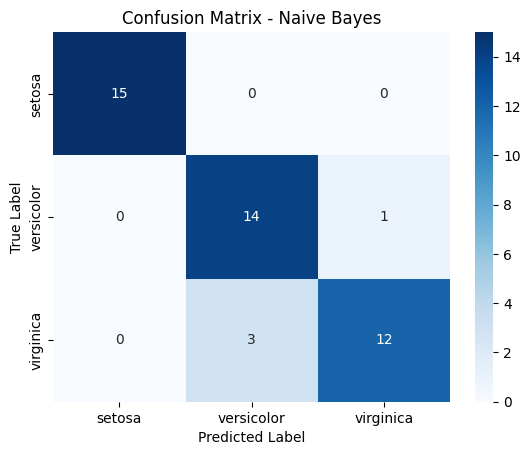


Probabilitas untuk 5 data pertama:
          setosa    versicolor  virginica
0  8.133040e-287  4.099741e-07   1.000000
1  7.203463e-132  9.955071e-01   0.004493
2  6.902840e-164  8.471765e-01   0.152824
3  2.977515e-143  6.679599e-01   0.332040
4  4.843589e-169  1.036414e-01   0.896359


In [ ]:
# IMPLEMENTASI NAIVE BAYES DENGAN SCIKIT-LEARN

import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Gaussian Naive Bayes (untuk data numerik)
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Prediksi
y_pred = gnb.predict(X_test)

# Evaluasi
print(f"Akurasi: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Lihat probabilitas posterior
probabilities = gnb.predict_proba(X_test[:5])
print("\nProbabilitas untuk 5 data pertama:")
print(pd.DataFrame(probabilities, columns=iris.target_names))

In [ ]:
# IMPLEMENTASI K-NN DENGAN SCIKIT-LEARN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score
import numpy as np

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Normalisasi SANGAT PENTING untuk k-NN!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# k-NN dengan k=5
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn.fit(X_train, y_train)

# Prediksi
y_pred = knn.predict(X_test)
print(f"Akurasi (k=5): {accuracy_score(y_test, y_pred):.4f}")

# Tuning parameter k dengan cross-validation
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nParameter terbaik: {grid_search.best_params_}")
print(f"Akurasi CV terbaik: {grid_search.best_score_:.4f}")

# Evaluasi model terbaik
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)
print(f"Akurasi test set: {accuracy_score(y_test, y_pred_best):.4f}")

Akurasi (k=5): 0.9444

Parameter terbaik: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Akurasi CV terbaik: 0.9753
Akurasi test set: 0.9815


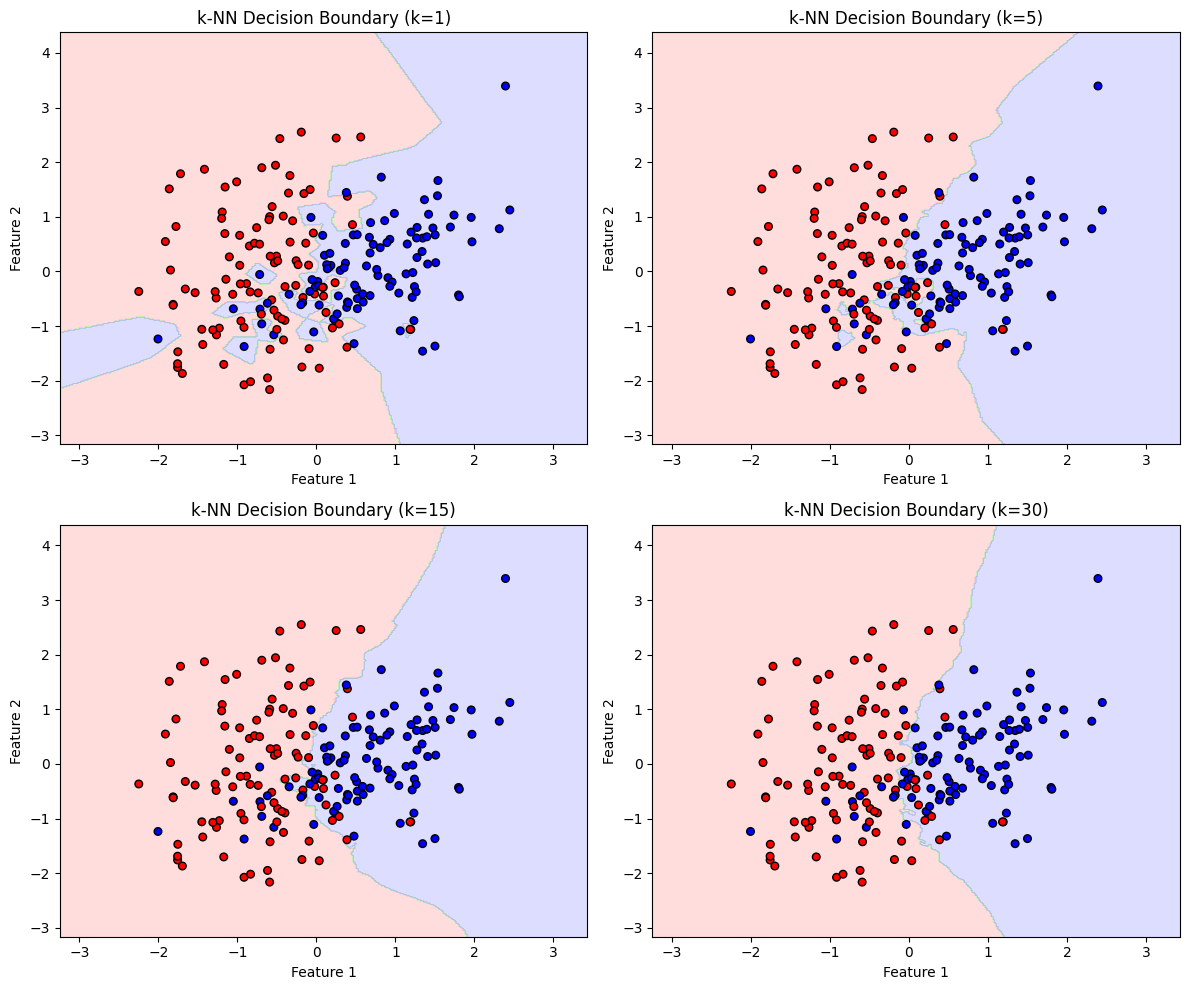

In [ ]:
# VISUALISASI DECISION BOUNDARY K-NN

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

# Generate dataset 2D untuk visualisasi
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Normalisasi
X = StandardScaler().fit_transform(X)

# Buat model untuk berbagai nilai k
k_values = [1, 5, 15, 30]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Warna untuk plot
cmap_background = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_points = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

for idx, k in enumerate(k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)

    # Plot decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap=cmap_background)
    axes[idx].scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap=cmap_points,
        edgecolor='black',
        s=30
    )

    axes[idx].set_title(f'k-NN Decision Boundary (k={k})')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Observasi:
# - k=1: boundary sangat kompleks (overfitting)
# - k=5: boundary lebih halus
# - k=15: semakin smooth
# - k=30: terlalu smooth (underfitting)

In [ ]:
# PERBANDINGAN PERFORMA NAIVE BAYES VS K-NN

from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# Generate berbagai jenis dataset
datasets = {
    'Linear': make_classification(
        n_samples=500,
        n_features=10,
        n_informative=8,
        random_state=42
    ),
    'Moons': make_moons(
        n_samples=500,
        noise=0.1,
        random_state=42
    ),
    'Circles': make_circles(
        n_samples=500,
        noise=0.05,
        factor=0.5,
        random_state=42
    )
}

# Model
models = {
    'Naive Bayes': GaussianNB(),
    'k-NN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'k-NN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'k-NN (k=15)': KNeighborsClassifier(n_neighbors=15)
}

# Bandingkan performa
results = []

for dataset_name, (X, y) in datasets.items():
    # Normalisasi untuk k-NN
    X_scaled = StandardScaler().fit_transform(X)

    for model_name, model in models.items():
        if 'k-NN' in model_name:
            X_use = X_scaled
        else:
            X_use = X  # NB tidak perlu normalisasi untuk data ini

        scores = cross_val_score(
            model,
            X_use,
            y,
            cv=5,
            scoring='accuracy'
        )

        results.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Mean Accuracy': scores.mean(),
            'Std': scores.std()
        })

results_df = pd.DataFrame(results)
print(results_df.round(4))

# Pivot table untuk perbandingan mudah
pivot = results_df.pivot(
    index='Dataset',
    columns='Model',
    values='Mean Accuracy'
)

print("\nPerbandingan Akurasi Rata-rata:")
print(pivot.round(4))

    Dataset        Model  Mean Accuracy     Std
0    Linear  Naive Bayes          0.730  0.0316
1    Linear   k-NN (k=3)          0.894  0.0242
2    Linear   k-NN (k=7)          0.886  0.0102
3    Linear  k-NN (k=15)          0.880  0.0352
4     Moons  Naive Bayes          0.870  0.0443
5     Moons   k-NN (k=3)          1.000  0.0000
6     Moons   k-NN (k=7)          1.000  0.0000
7     Moons  k-NN (k=15)          1.000  0.0000
8   Circles  Naive Bayes          1.000  0.0000
9   Circles   k-NN (k=3)          1.000  0.0000
10  Circles   k-NN (k=7)          1.000  0.0000
11  Circles  k-NN (k=15)          1.000  0.0000

Perbandingan Akurasi Rata-rata:
Model    Naive Bayes  k-NN (k=15)  k-NN (k=3)  k-NN (k=7)
Dataset                                                  
Circles         1.00         1.00       1.000       1.000
Linear          0.73         0.88       0.894       0.886
Moons           0.87         1.00       1.000       1.000
